# Loan  Default Case
## BI Project
### Loading Libraries that will be useful in our project

In [2]:
#For Data loading and manipulation
import pandas as pd
import numpy as np

# For Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# For Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc

# For the Machine Learning Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# Treating imbalanced data
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler


### Loading and inspecting the data

In [3]:


# Load the dataset
df = pd.read_csv("D:\\MSC_BI\\BI\\Project\\Data\\mycsvfile.csv")

# Display the first few rows
df.head(10)


,loan_amnt,term,sub_grade,emp_length,annual_inc,loan_status,dti,mths_since_recent_inq,revol_util,num_op_rev_tl,...,addr_state__SD,addr_state__TN,addr_state__TX,addr_state__UT,addr_state__VA,addr_state__VT,addr_state__WA,addr_state__WI,addr_state__WV,addr_state__WY
0,3600.0,1.0,24.0,10.0,55000.0,0.0,5.91,4.0,29.7,4.0,...,0,0,0,0,0,0,0,0,0,0
1,20000.0,2.0,14.0,10.0,63000.0,0.0,10.78,10.0,56.2,4.0,...,0,0,0,0,0,0,0,0,0,0
2,10400.0,2.0,51.0,3.0,104433.0,0.0,25.37,1.0,64.5,7.0,...,0,0,0,0,0,0,0,0,0,0
3,20000.0,1.0,11.0,10.0,85000.0,0.0,17.61,8.0,5.7,3.0,...,0,0,0,0,0,0,0,0,0,0
4,10000.0,1.0,2.0,6.0,85000.0,0.0,13.07,1.0,34.5,13.0,...,0,0,0,0,0,0,0,0,0,0
5,8000.0,1.0,15.0,10.0,42000.0,0.0,34.80,10.0,39.1,5.0,...,0,0,0,0,0,0,0,0,0,0
6,1400.0,1.0,22.0,3.0,64000.0,0.0,34.95,18.0,67.2,12.0,...,0,0,0,0,0,0,0,0,0,0
7,9600.0,1.0,4.0,8.0,60000.0,0.0,22.44,9.0,59.4,4.0,...,0,0,0,0,0,0,0,0,0,0
8,25000.0,1.0,4.0,10.0,109000.0,0.0,26.02,0.0,54.3,5.0,...,0,0,0,0,1,0,0,0,0,0
9,8650.0,1.0,43.0,8.0,55000.0,0.0,25.49,0.0,46.0,17.0,...,0,0,0,0,0,0,0,0,0,0


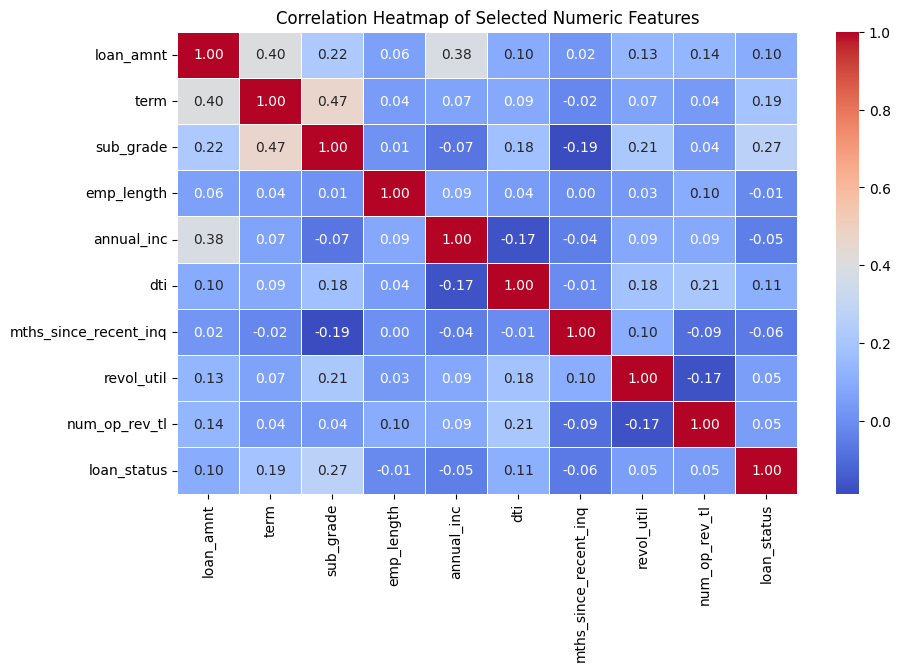

In [4]:
#correlation heatmap of the variables-will be helpful in report

# Only numeric features for correlation
numeric_cols = ['loan_amnt', 'term', 'sub_grade', 'emp_length', 'annual_inc',
                'dti', 'mths_since_recent_inq', 'revol_util', 'num_op_rev_tl']

# Compute correlation matrix
corr_matrix = df[numeric_cols + ['loan_status']].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Selected Numeric Features")
plt.show()


In [5]:
# Check the shape (rows and columns)
df.shape

# See column names and types
df.info()

# Look at basic statistics for numeric columns
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 848454 entries, 0 to 848453
Data columns (total 66 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   loan_amnt                 848454 non-null  float64
 1   term                      848454 non-null  float64
 2   sub_grade                 848454 non-null  float64
 3   emp_length                848454 non-null  float64
 4   annual_inc                848454 non-null  float64
 5   loan_status               848454 non-null  float64
 6   dti                       848454 non-null  float64
 7   mths_since_recent_inq     848454 non-null  float64
 8   revol_util                848454 non-null  float64
 9   num_op_rev_tl             848454 non-null  float64
 10  home_ownership__ANY       848454 non-null  int64  
 11  home_ownership__MORTGAGE  848454 non-null  int64  
 12  home_ownership__NONE      848454 non-null  int64  
 13  home_ownership__OTHER     848454 non-null  i

,loan_amnt,term,sub_grade,emp_length,annual_inc,loan_status,dti,mths_since_recent_inq,revol_util,num_op_rev_tl,...,addr_state__SD,addr_state__TN,addr_state__TX,addr_state__UT,addr_state__VA,addr_state__VT,addr_state__WA,addr_state__WI,addr_state__WV,addr_state__WY
count,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000,...,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000,848454.000000
mean,14685.697457,1.268249,21.268733,6.145857,72400.496752,0.207527,18.575478,6.705665,52.912851,8.344402,...,0.002113,0.015782,0.085755,0.007478,0.027221,0.002114,0.022196,0.013875,0.003502,0.002349
std,8280.771514,0.443048,12.763837,3.662421,25589.248556,0.405536,8.199811,5.820888,23.374794,4.340655,...,0.045922,0.124630,0.280002,0.086153,0.162728,0.045934,0.147320,0.116971,0.059071,0.048409
min,1000.000000,1.000000,1.000000,0.000000,35000.990000,0.000000,-1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8000.000000,1.000000,12.000000,3.000000,51500.000000,0.000000,12.510000,2.000000,35.700000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,13000.000000,1.000000,21.000000,7.000000,67600.000000,0.000000,18.130000,5.000000,53.200000,8.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,20000.000000,2.000000,31.000000,10.000000,90000.000000,0.000000,24.360000,10.000000,70.700000,11.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,40000.000000,2.000000,65.000000,10.000000,144999.000000,1.000000,45.000000,25.000000,148.000000,35.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Select features and define target

In [6]:


# We'll keep these numerical features + already encoded categorical columns
selected_columns = [
    'loan_amnt', 'term', 'sub_grade', 'emp_length', 'annual_inc',
    'dti', 'mths_since_recent_inq', 'revol_util', 'num_op_rev_tl', 'loan_status'
]

# Keep all dummy variables (they start with 'home_ownership__' or 'addr_state__')
dummy_columns = [col for col in df.columns if col.startswith('home_ownership__') or col.startswith('addr_state__')]

# Combine all features
final_columns = selected_columns[:-1] + dummy_columns  # Exclude 'loan_status' from features
X = df[final_columns]  # Features
y = df['loan_status']  # Target

# Quick check on the shape of features and target
X.shape, y.shape



((848454, 65), (848454,))

### Normalizing/scaling the Numerical Features

In [7]:


# Initialize the scaler
scaler = StandardScaler()

# Apply scaling to numerical columns only (avoid scaling dummies so we won't scale them)
num_cols = ['loan_amnt', 'term', 'sub_grade', 'emp_length', 'annual_inc',
            'dti', 'mths_since_recent_inq', 'revol_util', 'num_op_rev_tl']

# Apply scaling ONLY to numeric columns
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

# Preview the scaled data
X_scaled[num_cols].describe()



,loan_amnt,term,sub_grade,emp_length,annual_inc,dti,mths_since_recent_inq,revol_util,num_op_rev_tl
count,8.484540e+05,8.484540e+05,8.484540e+05,8.484540e+05,8.484540e+05,8.484540e+05,8.484540e+05,8.484540e+05,8.484540e+05
mean,3.617809e-17,5.801894e-17,-7.021230e-17,9.134968e-17,-2.515315e-15,-5.567741e-16,-2.696608e-17,-4.293133e-16,1.648950e-16
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-1.652709e+00,-6.054628e-01,-1.587982e+00,-1.678087e+00,-1.461533e+00,-2.387310e+00,-1.152001e+00,-2.263673e+00,-1.922384e+00
25%,-8.073766e-01,-6.054628e-01,-7.261718e-01,-8.589560e-01,-8.167692e-01,-7.397099e-01,-8.084106e-01,-7.363856e-01,-7.704837e-01
50%,-2.035678e-01,-6.054628e-01,-2.105430e-02,2.332182e-01,-1.875983e-01,-5.432785e-02,-2.930250e-01,1.228455e-02,-7.934331e-02
75%,6.417646e-01,1.651629e+00,7.624096e-01,1.052349e+00,6.877698e-01,7.054462e-01,5.659510e-01,7.609547e-01,6.117971e-01
max,3.057000e+00,1.651629e+00,3.426187e+00,1.052349e+00,2.837072e+00,3.222579e+00,3.142879e+00,4.067938e+00,6.140920e+00


# Train-Test Split + Set Models
# 1. Logistic Regression

In [11]:
# i. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# ii. Train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

#Test the model
#Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:\n", classification_report(y_test, y_pred,digits=3))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7935305938441048
F1 Score: 0.16217896599550433
ROC-AUC: 0.7080077752544691

Classification Report:
               precision    recall  f1-score   support

         0.0      0.805     0.976     0.882    134476
         1.0      0.514     0.096     0.162     35215

    accuracy                          0.794    169691
   macro avg      0.659     0.536     0.522    169691
weighted avg      0.744     0.794     0.733    169691


Confusion Matrix:
 [[131264   3212]
 [ 31824   3391]]



What the results mean:


| Metric       | Value  | What it Means                                                                   |
| ------------ | ------ | ------------------------------------------------------------------------------- |
| **Accuracy** | `0.79` | The model correctly predicts \~79% of all loan outcomes.                        |
| **F1 Score** | `0.16` | There's a big imbalance. The model struggles to detect loan defaults well.      |
| **ROC-AUC**  | `0.71` | Decent discrimination between defaults and non-defaults, but could be improved. |


Our accuracy is high, but we still need to evaluate its relaibility.

Loan default datasets are imbalanced , meaning most loans are not defaults.

Therefore:

-The model gets many “non-default” predictions correct.

-But it likely misses many actual defaults, which could be why  why our F1 Score is low.

-The ROC-AUC of 0.71 shows the model is better than random but still leaves room for improvement.




## 1.1 5-Fold Cross-Validation of the model

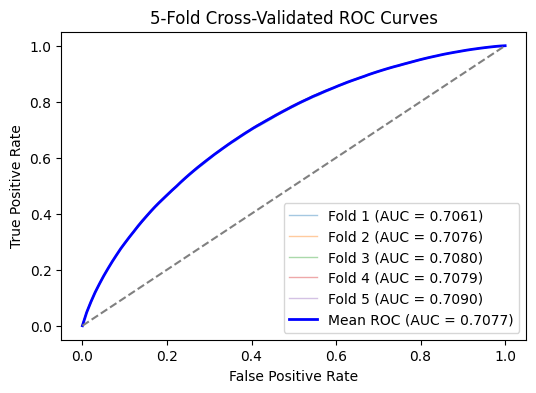

AUC scores for each fold: [np.float64(0.7061187218607666), np.float64(0.7075872995744374), np.float64(0.7080056100173838), np.float64(0.7078986019638692), np.float64(0.7089725294889331)]
Mean AUC: 0.707716552581078


In [14]:


# Set up stratified 10-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize model
model = LogisticRegression(max_iter=1000, class_weight='balanced')

# To store AUCs for each fold
fold_aucs = []

# ROC plotting values (optional)
tprs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(6, 4))

for i, (train_idx, test_idx) in enumerate(cv.split(X_scaled, y)):
    # Use .iloc if X_scaled and y are DataFrames or Series
    X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    fold_aucs.append(roc_auc)  # Store AUC
    
    # Interpolate for mean curve
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    plt.plot(fpr, tpr, lw=1, alpha=0.4, label=f"Fold {i+1} (AUC = {roc_auc:.4f})")

# Mean ROC curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)

plt.plot(mean_fpr, mean_tpr, color='blue', lw=2, label=f"Mean ROC (AUC = {mean_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title("5-Fold Cross-Validated ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Print AUCs
print("AUC scores for each fold:", fold_aucs)
print("Mean AUC:", np.mean(fold_aucs))



## 1.2 Visulizing Logistic Regression Model

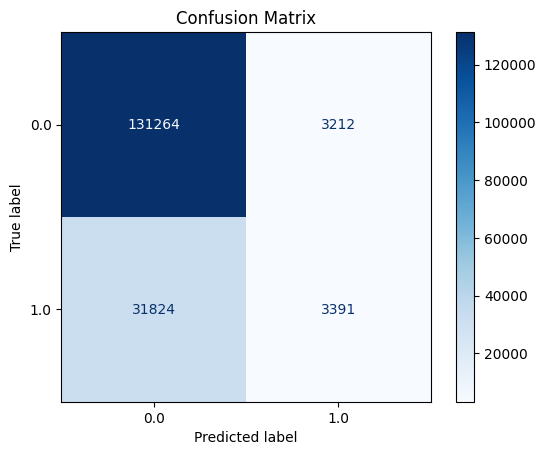

In [12]:
#5:Confusion Matrix & ROC Curve
#To  help us see the kinds of mistakes our model makes.
from sklearn.metrics import ConfusionMatrixDisplay

#i. Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


What the confusion matrix means:


|                            | **Predicted: No Default (0)**  | **Predicted: Default (1)**   |
| -------------------------- | ------------------------------ | ---------------------------- |
| **Actual: No Default (0)** | **131,264** (True Negatives) | 3,212 (False Positives)    |
| **Actual: Default (1)**    | 31,824 (False Negatives)     | **3,391** (True Positives) |


Further elaboration:

Good thing about the result:

-The model correctly predicts non-defaults (0) very well i.e High True Negatives

-Very few false alarms i.e Low False Positives

What could need improvement:

-It misses many actual defaults i.e there are High False Negatives

That’s why our F1 Score is low (it measures how well the model catches defaults)

Why this could be happening:
This is typical of imbalanced datasets. There are far more “non-default” cases than “default” ones, so the model learns to play it safe and just predict “no default” most of the time.



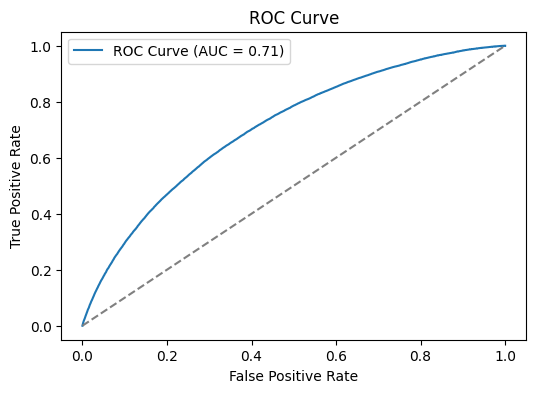

In [13]:
#ii. Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


What our ROC Curve means


The curve rises above the diagonal (random guess), which shows the model has some predictive power

Our AUC = 0.71, which is:

-Better than chance (0.5)

-But not “great” . AUC ≥ 0.8 is usually considered strong

Our Conclusion So Far:

Our  baseline model:

1. Predicts non-defaults well

2. Struggles with identifying defaults (high false negatives)

3. ROC-AUC of 0.71 gives us a solid starting point  From here, we shall try and optimize!



### 2. Treating imbalanced data

### 2.1. Oversampling (SMOTE)

Class distribution after SMOTE: Counter({0.0: 672377, 1.0: 672377})
Logistic Regression Accuracy: 0.6804473677361303

Confusion Matrix:
 [[98769 35707]
 [50237 84238]]

Classification Report:
               precision    recall  f1-score   support

         0.0      0.663     0.734     0.697    134476
         1.0      0.702     0.626     0.662    134475

    accuracy                          0.680    268951
   macro avg      0.683     0.680     0.680    268951
weighted avg      0.683     0.680     0.680    268951

Accuracy: 0.6804473677361303
F1 Score: 0.6621963682100463
ROC-AUC: 0.7569697350150925


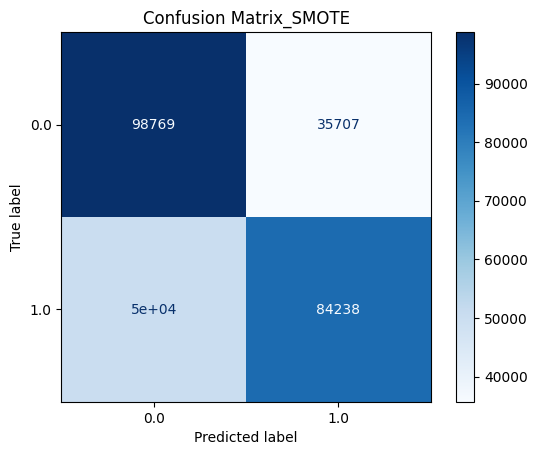

In [8]:

# Apply SMOTE
sm = SMOTE(random_state=42)
X_new, y_new = sm.fit_resample(X_scaled, y)

# Show new class distribution
print("Class distribution after SMOTE:", Counter(y_new))
X_resampled, X_test2, y_resampled, y_test2 = train_test_split(X_new, y_new, test_size=0.2, random_state=42, stratify=y_new)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train model on SMOTE-resampled data
log_reg_resampled = LogisticRegression(solver='liblinear', random_state=42)
log_reg_resampled.fit(X_resampled, y_resampled)

# Predict on original test set
y_repred = log_reg_resampled.predict(X_test2)

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test2, y_repred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test2, y_repred))
print("\nClassification Report:\n", classification_report(y_test2, y_repred,digits=3))

accuracy2 = accuracy_score(y_test2, y_repred)
f12 = f1_score(y_test2, y_repred)
roc_auc2 = roc_auc_score(y_test2, log_reg_resampled.predict_proba(X_test2)[:, 1])

print("Accuracy:", accuracy2)
print("F1 Score:", f12)
print("ROC-AUC:", roc_auc2)

ConfusionMatrixDisplay.from_estimator(log_reg_resampled, X_test2, y_test2, cmap='Blues')
plt.title("Confusion Matrix_SMOTE")
plt.show()

In [10]:
y_probs = log_reg_resampled.predict_proba(X_test2)[:, 1]
fpr1, tpr1, thresholds = roc_curve(y_test2, y_probs)
roc_auc1 = auc(fpr1, tpr1)


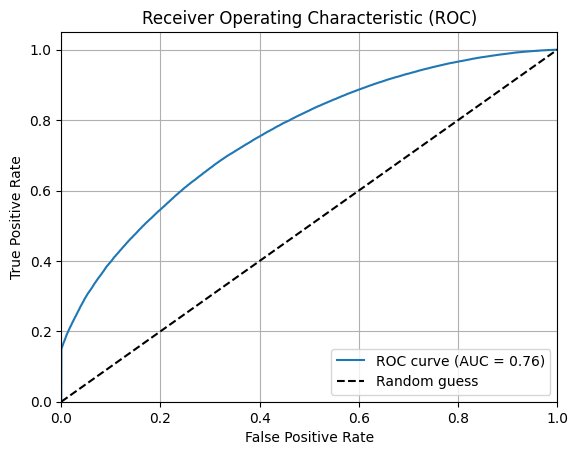

In [11]:
plt.figure()
plt.plot(fpr1, tpr1, label=f"ROC curve (AUC = {roc_auc1:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid()
plt.show()


### 2. Undersampling (RUS)

Counter({0.0: 176077, 1.0: 176077})
Class distribution after undersampling: Counter({1.0: 140862, 0.0: 140861})
Counter({0.0: 35216, 1.0: 35215})
Logistic Regression Accuracy: 0.6503528275901237

Logistic Regression Confusion Matrix:
 [[23711 11505]
 [13121 22094]]

Logistic Regression Classification Report:
               precision    recall  f1-score   support

         0.0      0.644     0.673     0.658     35216
         1.0      0.658     0.627     0.642     35215

    accuracy                          0.650     70431
   macro avg      0.651     0.650     0.650     70431
weighted avg      0.651     0.650     0.650     70431

F1 Score: 0.6421367744935623
ROC-AUC: 0.7082086339170628


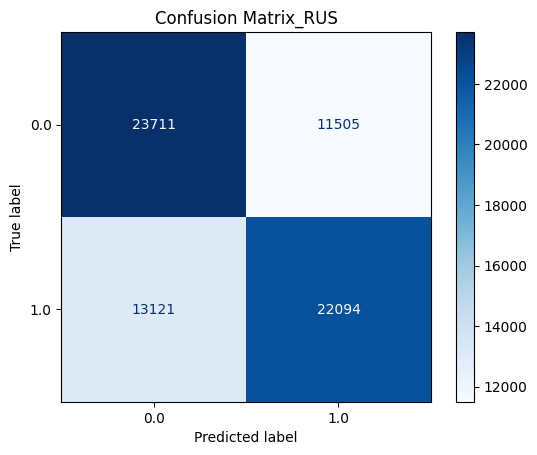

In [12]:

# Create the undersampler
undersampler = RandomUnderSampler(random_state=42)

# Apply undersampling only to training data (not test data!)
X_new2, y_new2 = undersampler.fit_resample(X_scaled, y)
X_train_under, X_test3, y_train_under, y_test3 = train_test_split(X_new2, y_new2, test_size=0.2, random_state=42, stratify=y_new2)

# Check class distribution
from collections import Counter
print(Counter(y_new2))
print("Class distribution after undersampling:", Counter(y_train_under))
print(Counter(y_test3))

# Create the model
log_reg_under = LogisticRegression(solver='liblinear', random_state=42)

# Fit the model
log_reg_under.fit(X_train_under, y_train_under)

# Predict on test set
y_pred = log_reg_under.predict(X_test3)

# Evaluate performance
accuracy = accuracy_score(y_test3, y_pred)
conf_matrix = confusion_matrix(y_test3, y_pred)
class_report = classification_report(y_test3, y_pred, digits=3)

# Print results
print("Logistic Regression Accuracy:", accuracy)
print("\nLogistic Regression Confusion Matrix:\n", conf_matrix)
print("\nLogistic Regression Classification Report:\n", class_report)

f13 = f1_score(y_test3, y_pred)
roc_auc3 = roc_auc_score(y_test3, log_reg_under.predict_proba(X_test3)[:, 1])

print("F1 Score:", f13)
print("ROC-AUC:", roc_auc3)

ConfusionMatrixDisplay.from_estimator(log_reg_under, X_test3, y_test3, cmap='Blues')
plt.title("Confusion Matrix_RUS")
plt.show()

In [28]:
y_probs = log_reg_under.predict_proba(X_test3)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test3, y_probs)
roc_auc = auc(fpr, tpr)


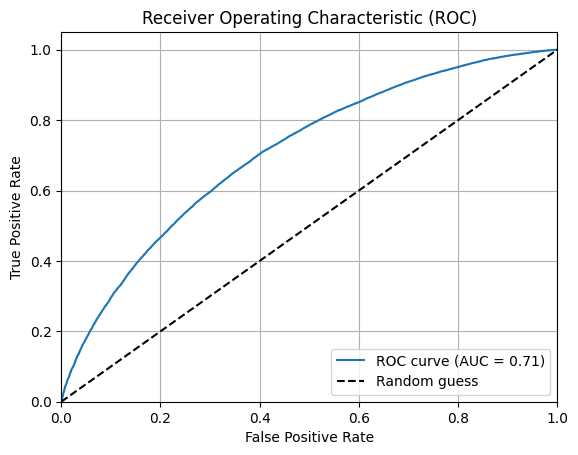

In [29]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid()
plt.show()


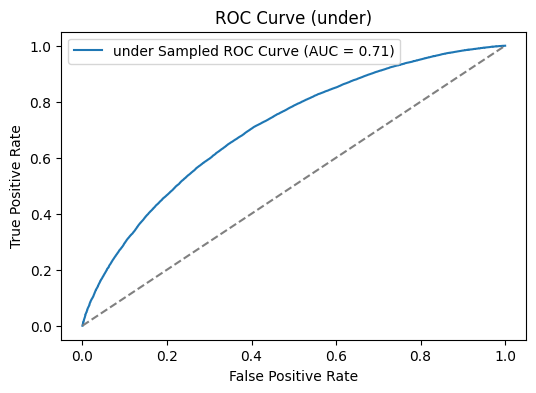

In [ ]:
# New ROC Curve
fpr, tpr,  = roc_curve(y_test3, log_reg_under.predict_proba(X_test3)[:, 1])
plt.figure(figsize=(6, 4))
plt.plot(fpr_bal, tpr_bal, label=f"under Sampled ROC Curve (AUC = {roc_auc3:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (under)")
plt.legend()
plt.show()


### 2.3. Balanced Class Weight

In [25]:
# This tells Logistic Regression to give more attention to the minority class i.e defaults when learning.
#Used class_weight='balanced' for Logistic Regression to improve detection of default cases in an imbalanced dataset.
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

# Predict again
y_pred_balanced = model_balanced.predict(X_test)

# Re-evaluate
accuracy_bal = accuracy_score(y_test, y_pred_balanced)
f1_bal = f1_score(y_test, y_pred_balanced)
roc_auc_bal = roc_auc_score(y_test, model_balanced.predict_proba(X_test)[:, 1])

print("Balanced Accuracy:", accuracy_bal)
print("Balanced F1 Score:", f1_bal)
print("Balanced ROC-AUC:", roc_auc_bal)



Balanced Accuracy: 0.6647356945017384
Balanced F1 Score: 0.43789706652438964
Balanced ROC-AUC: 0.7089725294889331


| Metric   | Before (Unbalanced) | After (Balanced) | Change              |
| -------- | ------------------- | ---------------- | ------------------- |
| Accuracy | 0.79                | **0.66**         |  expected drop |
| F1 Score | 0.16                | **0.44**         |  big gain    |
| ROC-AUC  | 0.71                | **0.71**         |  slightly better
 |


 What This Means:

-Accuracy dropped because the model now dares to predict more defaults. This is a good trade-off for our use case.

-F1 Score improved dramatically. We are now catching significantly more actual defaults while balancing false positives.

-ROC-AUC is steady, still a decent 0.71.

This model is far more useful in real-world credit risk settings, where catching defaults (even with some false alarms) is more important than pure accuracy.


In [59]:
# Evaluation Metrics
# Logistic Regression (Balanced)
print("Classification Report – Balanced Logistic Regression:")
print(classification_report(y_test, y_pred_balanced, digits=3))




Classification Report – Balanced Logistic Regression:
              precision    recall  f1-score   support

         0.0      0.874     0.674     0.761    134476
         1.0      0.335     0.628     0.437     35215

    accuracy                          0.665    169691
   macro avg      0.605     0.651     0.599    169691
weighted avg      0.762     0.665     0.694    169691



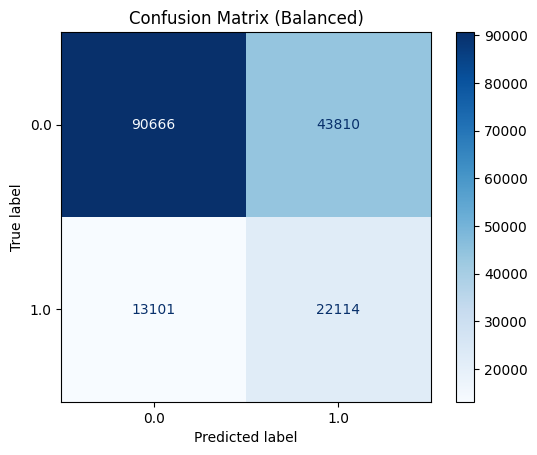

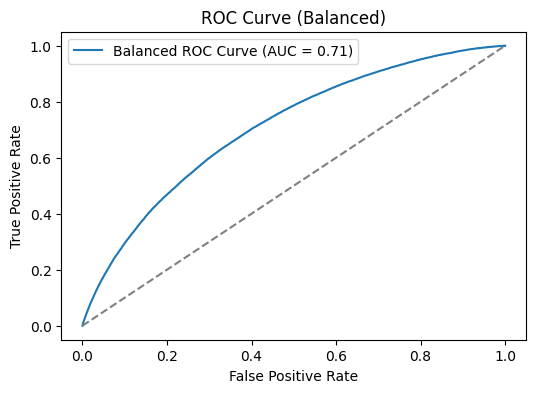

In [60]:
#Plotting the new confusion matrix and ROC curve again with the new model
ConfusionMatrixDisplay.from_estimator(model_balanced, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix (Balanced)")
plt.show()

# New ROC Curve
fpr_bal, tpr_bal, _ = roc_curve(y_test, model_balanced.predict_proba(X_test)[:, 1])
plt.figure(figsize=(6, 4))
plt.plot(fpr_bal, tpr_bal, label=f"Balanced ROC Curve (AUC = {roc_auc_bal:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Balanced)")
plt.legend()
plt.show()



**For Confusion Matrix (Balanced)**

|                            | Predicted: No Default (0)  | Predicted: Default (1)     |
| -------------------------- | -------------------------- | -------------------------- |
| **Actual: No Default (0)** |  90,666 (True Negatives)  |  43,810 (False Positives) |
| **Actual: Default (1)**    |  13,101 (False Negatives) |  22,114 (True Positives)  |


What This Means:
-We now catch 22,114 defaults vs. only 3,391 before

-We sacrificed some accuracy, but the model is now way better at flagging risk

-The trade-off is worth it for credit risk: it’s better to flag potential defaulters and review manually than miss them

**For ROC Curve (Balanced)**

-Still strong with an AUC = 0.71

-Tells us that the model has good separation power between defaults and non-defaults

# 2. Random Forest

In [ ]:
##**Now using a different model: Random Forest**
## training the model with under sampled data



# Sample 100,000 rows randomly
X_sample = X_train_under.sample(n=100000, random_state=42)
y_sample = y_train_under.loc[X_sample.index]

# Re-train Random Forest on this smaller sample
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_under, y_train_under)




RandomForestClassifier(random_state=42)

We trained a Random Forest Classifier with:



*   n_estimators = 100 trees
*   class_weight = 'balanced' to handle class imbalance

* A sample of 100,000 rows from the training data (to reduce computation time)

Random Forest was chosen to capture non-linear relationships and provide an ensemble-based benchmark.





In [14]:
#2. Predict and Evaluate the model
# Predict on the full test set
y_pred_rf = rf_model.predict(X_test3)
y_prob_rf = rf_model.predict_proba(X_test3)[:, 1]  # Needed for ROC-AUC

# Metrics
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

accuracy_rf = accuracy_score(y_test3, y_pred_rf)
f1_rf = f1_score(y_test3, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test3, y_prob_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest F1 Score:", f1_rf)
print("Random Forest ROC-AUC:", roc_auc_rf)


Random Forest Accuracy: 0.6461075378739476
Random Forest F1 Score: 0.6481060552582909
Random Forest ROC-AUC: 0.7006951222847797


In [ ]:
#Evaluation Metrics
print("Classification Report – Random Forest:")
print(classification_report(y_test3, y_pred_rf, digits=3))



Classification Report – Random Forest:
              precision    recall  f1-score   support

         0.0      0.648     0.640     0.644     35216
         1.0      0.644     0.652     0.648     35215

    accuracy                          0.646     70431
   macro avg      0.646     0.646     0.646     70431
weighted avg      0.646     0.646     0.646     70431



## 2.1 Visualizing RF Model

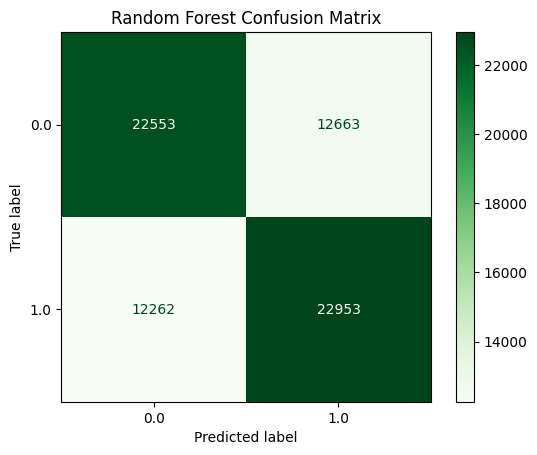

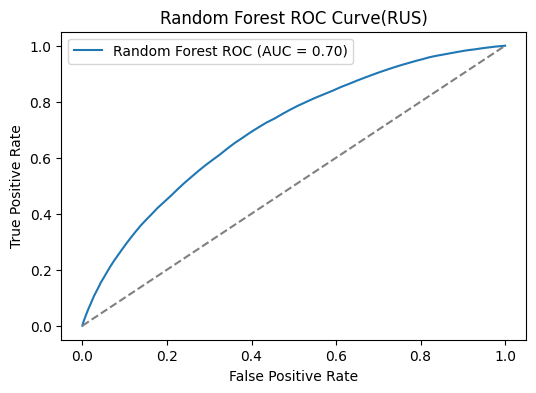

In [ ]:
#3.Plot the Confusion Matrix and ROC Curve

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test3, y_test3, cmap='Greens')
plt.title("Random Forest Confusion Matrix(RUS)")
plt.show()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test3, y_prob_rf)
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest ROC (AUC = {roc_auc_rf:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve(RUS)")
plt.legend()
plt.show()


In [30]:
##**Now using a different model: Random Forest**

#SMOTE data oversampling

# Sample 100,000 rows randomly
X_sample = X_resampled.sample(n=100000, random_state=42)
y_sample = y_resampled.loc[X_sample.index]

# Re-train Random Forest on this smaller sample
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X_resampled, y_resampled)




RandomForestClassifier(random_state=42)

Classification Report – Random Forest:
              precision    recall  f1-score   support

         0.0      0.845     0.916     0.879    134476
         1.0      0.908     0.832     0.868    134475

    accuracy                          0.874    268951
   macro avg      0.876     0.874     0.874    268951
weighted avg      0.876     0.874     0.874    268951

Random Forest Accuracy: 0.8737725459284404
Random Forest F1 Score: 0.8682456950583889
Random Forest ROC-AUC: 0.9418136451812649


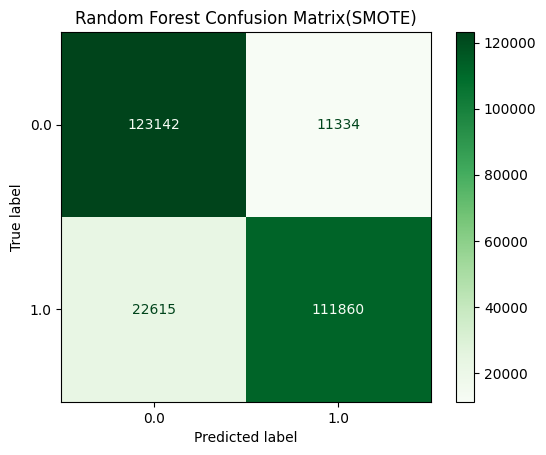

In [32]:


y_pred_rf2 = rf_model2.predict(X_test2)
y_prob_rf2 = rf_model2.predict_proba(X_test2)[:, 1]  

#Evaluation Metrics
print("Classification Report – Random Forest:")
print(classification_report(y_test2, y_pred_rf2, digits=3))

accuracy_rf2 = accuracy_score(y_test2, y_pred_rf2)
f1_rf2 = f1_score(y_test2, y_pred_rf2)
roc_auc_rf2 = roc_auc_score(y_test2, y_prob_rf2)

print("Random Forest Accuracy:", accuracy_rf2)
print("Random Forest F1 Score:", f1_rf2)
print("Random Forest ROC-AUC:", roc_auc_rf2)

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(rf_model2, X_test2, y_test2, cmap='Greens')
plt.title("Random Forest Confusion Matrix(SMOTE)")
plt.show()

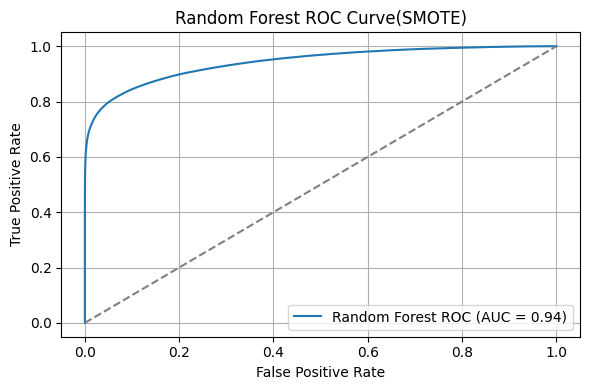

In [33]:
# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test2, y_prob_rf2)
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest ROC (AUC = {roc_auc_rf2:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve(SMOTE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
np.unique(y_prob_rf2).shape


(101,)

In [25]:
print(f"Unique predicted probabilities: {len(np.unique(y_prob_rf2))}")


Unique predicted probabilities: 101
